# **Unemployment Analysis in India using Python**

### **CodeAlpha Data Science Internship - Task 2**

**Intern Name:** Radhika

**Platform:** Google Colab

**Programming Language:** Python


## 📌 Project Objective

This project aims to analyze unemployment trends across different states of India using Python.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Upload and Load Dataset

The unemployment dataset is uploaded and loaded into a Pandas DataFrame for analysis.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


In [ ]:
data = pd.read_csv("Unemployment in India.csv")

## Step 2: Exploratory Data Analysis (EDA)

The dataset structure, missing values, and summary statistics are examined.

In [ ]:
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


# Dataset Information

The dataset information displays the number of records, column names, data types, and non-null values present in each column.

In [ ]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


# Statistical Summary

The statistical summary provides measures such as mean, standard deviation, minimum, maximum, and quartile values for numerical variables.

In [ ]:
data.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


# Missing Value Analysis

The dataset contains some missing values that need to be handled before performing further analysis and visualization.

## Step 3: Data Cleaning

Missing values are identified and handled to prepare the dataset for analysis.

In [ ]:
data = data.dropna()
data.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


# Data Cleaning Result

After removing missing values, the dataset contains no null values and is ready for analysis.*italicized text*

In [ ]:
data.shape

(740, 7)

In [ ]:
data.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
print(data.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


# Dataset Structure
Total Rows: 740
Total Columns: 7
Column names were verified successfully.
Dataset structure is suitable for visualization and analysis.

# Step 4: Data Visualization and Analysis

This section explores unemployment trends, labour participation rates, employment levels, and regional differences using graphical visualizations.

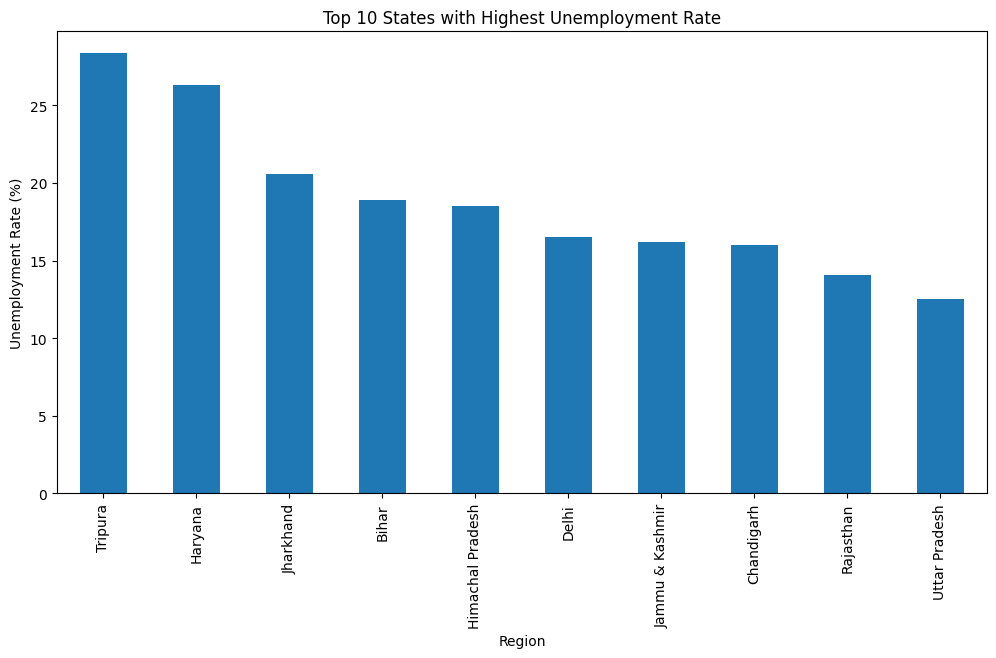

In [ ]:
top_states = data.groupby('Region')[' Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
top_states.head(10).plot(kind='bar')
plt.title('Top 10 States with Highest Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.show()

### Top 10 States with Highest Unemployment Rate

This visualization highlights the states with the highest average unemployment rates in India.

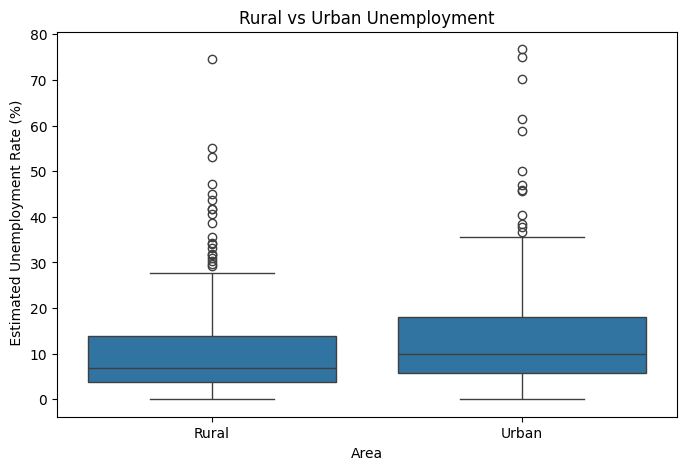

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Area', y=' Estimated Unemployment Rate (%)', data=data)
plt.title('Rural vs Urban Unemployment')
plt.show()

# Rural vs Urban Unemployment Comparison

The boxplot compares unemployment levels between rural and urban areas, helping to understand regional employment differences.

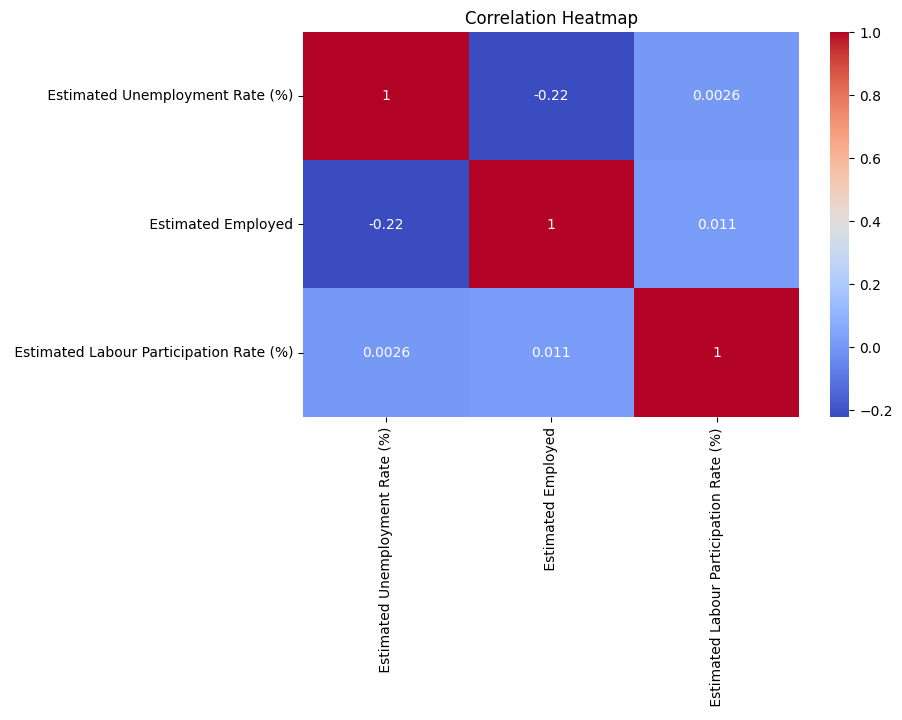

In [ ]:
numeric_data = data.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(8,5))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Correlation Analysis

The heatmap shows relationships among unemployment rate, employment level, and labour participation rate. Stronger correlations indicate closer relationships between variables.

/tmp/ipykernel_2134/158410108.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data[' Date'] = pd.to_datetime(data[' Date'])
/tmp/ipykernel_2134/158410108.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[' Date'] = pd.to_datetime(data[' Date'])


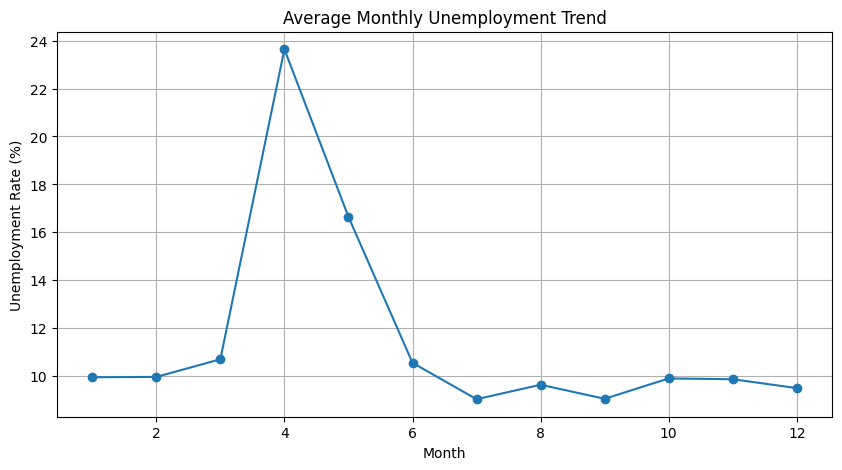

In [ ]:
data[' Date'] = pd.to_datetime(data[' Date'])

monthly = data.groupby(data[' Date'].dt.month)[' Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')
plt.title("Average Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# Monthly Unemployment Trend

This line chart illustrates how unemployment rates change over different months and helps identify seasonal trends.

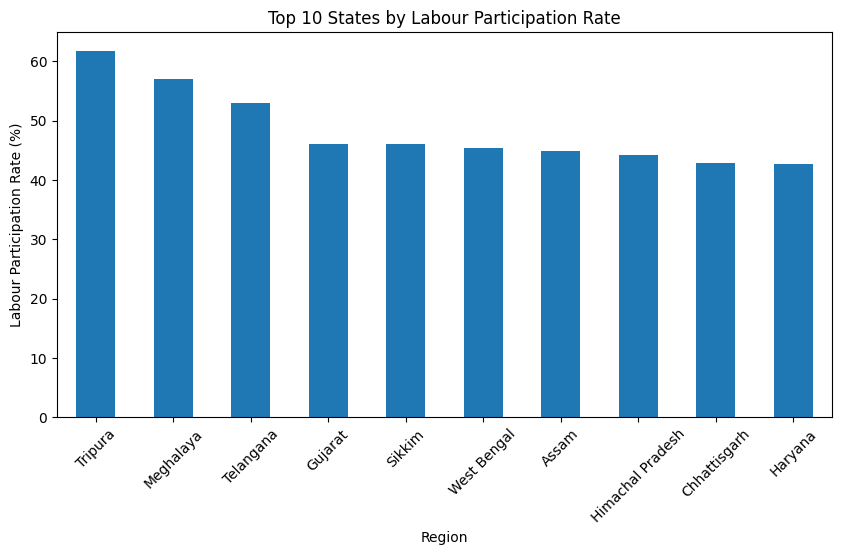

In [ ]:
top_labour = data.groupby('Region')[' Estimated Labour Participation Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_labour.plot(kind='bar')
plt.title("Top 10 States by Labour Participation Rate")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=45)
plt.show()

# Labour Participation Analysis

This visualization identifies the states with the highest labour participation rates, indicating greater workforce involvement.

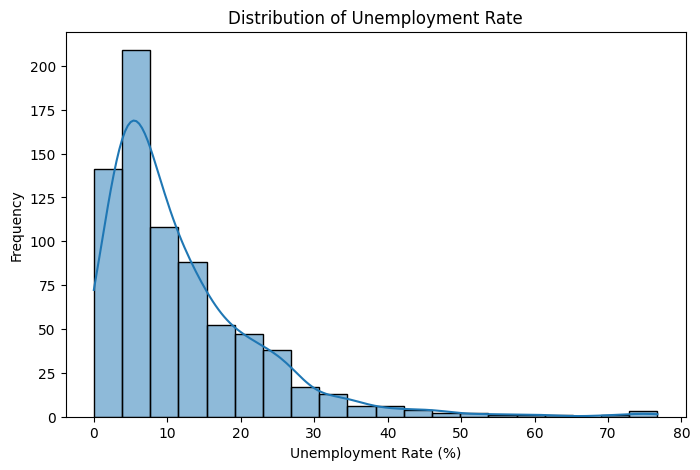

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data[' Estimated Unemployment Rate (%)'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

# Distribution of Unemployment Rate

The histogram displays how unemployment rates are distributed across observations and reveals the overall pattern of unemployment.

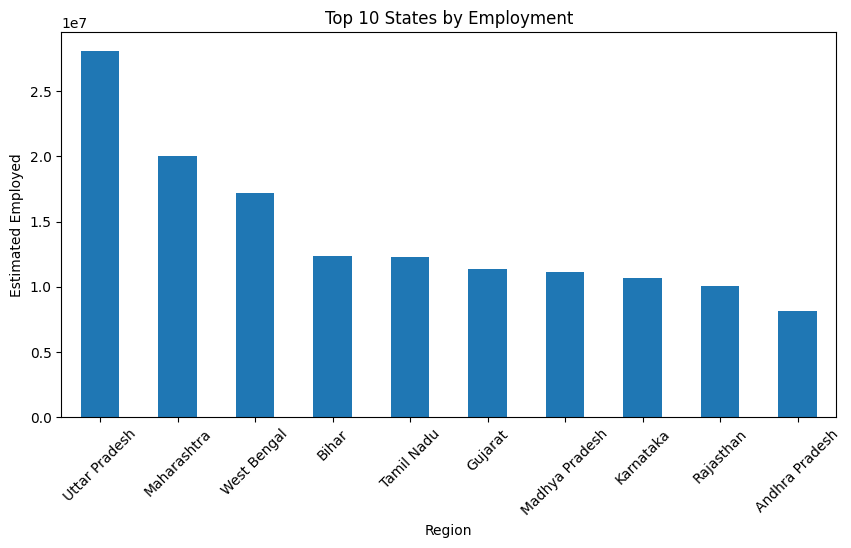

In [ ]:
top_emp = data.groupby('Region')[' Estimated Employed'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_emp.plot(kind='bar')
plt.title('Top 10 States by Employment')
plt.ylabel('Estimated Employed')
plt.xticks(rotation=45)
plt.show()

# Employment Distribution by State

This chart highlights states with the highest employment levels and provides insights into workforce concentration.

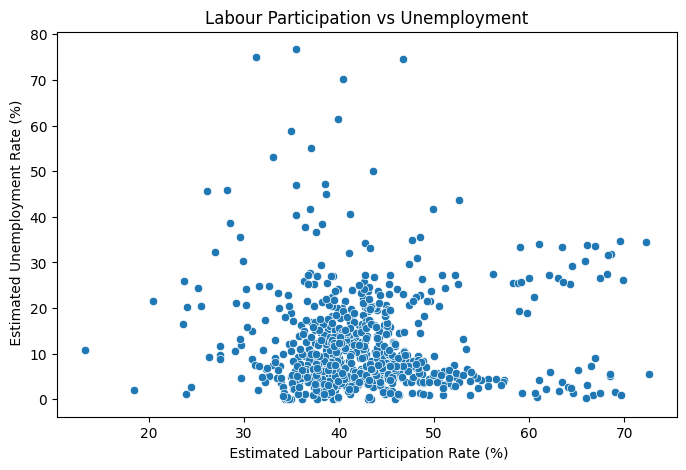

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=' Estimated Labour Participation Rate (%)',
    y=' Estimated Unemployment Rate (%)',
    data=data
)

plt.title('Labour Participation vs Unemployment')
plt.show()

# Labour Participation vs Unemployment

The scatter plot helps examine the relationship between labour participation and unemployment rates across observations.

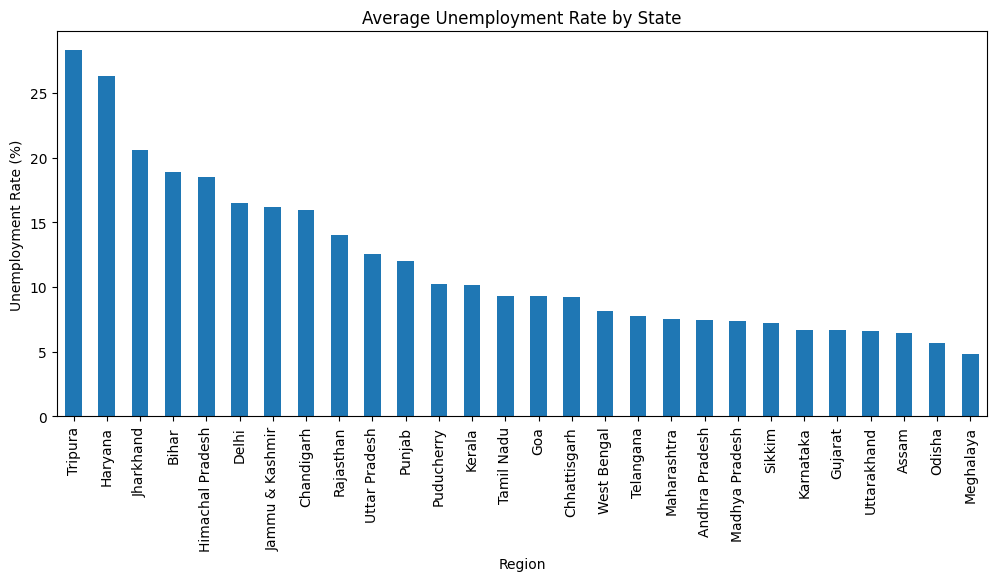

In [ ]:
region_avg = data.groupby('Region')[' Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
region_avg.plot(kind='bar')
plt.title('Average Unemployment Rate by State')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.show()

# Final Conclusion
Significant variations in unemployment rates exist across Indian states.
Labour participation rates differ among regions, indicating workforce diversity.
Rural and urban areas show different unemployment characteristics.
Employment levels and unemployment rates are influenced by regional economic conditions.
Data visualization helped identify important trends and patterns within the dataset.